In [217]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from cil.framework import ImageGeometry, ImageData
from cil.optimisation.functions import LeastSquares, Function, TotalVariation
from cil.optimisation.operators import IdentityOperator, LinearOperator, CompositionOperator, BlurringOperator
from cil.optimisation.algorithms import LADMM, PDHG
from cil.utilities.display import show2D
from cil.utilities import  noise

# CIL version 24.3.1

In [185]:
import cil
print(cil.__version__)

24.3.1.dev25+g2e29ec52b


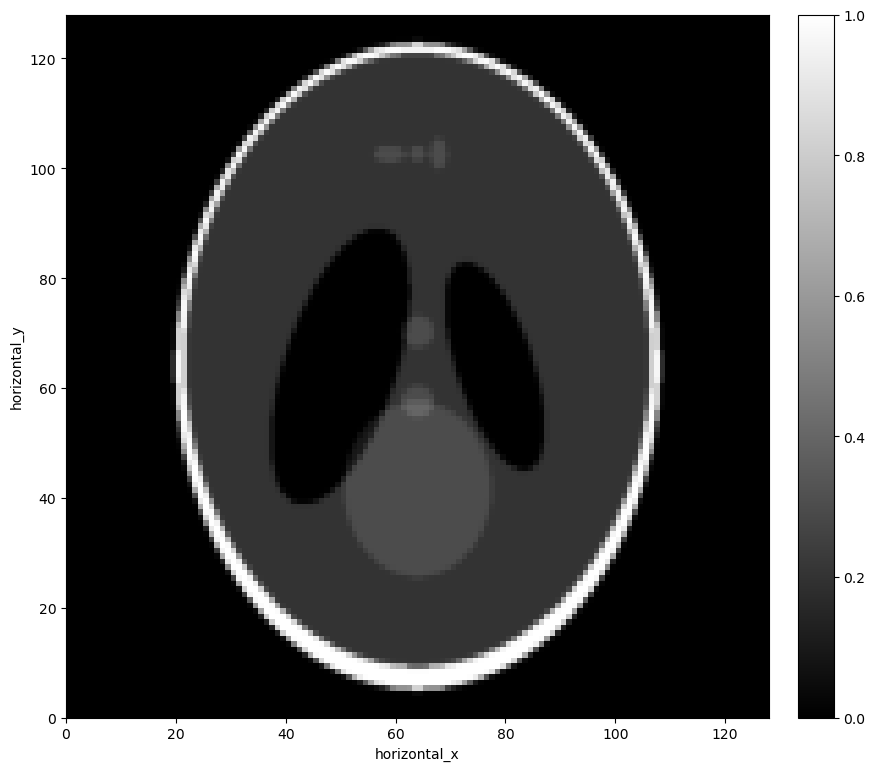

In [218]:
ig_image = ImageGeometry(voxel_num_x=128, voxel_num_y=128)
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
ground_truth_array = shepp_logan_phantom()
ground_truth_array = resize(ground_truth_array, [128,128])
ground_truth = ImageData(array = ground_truth_array, geometry = ig_image)
show2D(ground_truth)

# Morozov regularisation

The usual Tikhonov framework regularisation is as follows: $\underset{x}{\min}D(Ax,b) + \alpha\mathcal{R}(x)$ for $D$ the data-fit term, $\mathcal{R}$ the regulariser and $\alpha > 0$ the regularisation parameter. This framework is widely used but involves selecting a regularisation parameter which is not a trivial step. 

Morozov regularisation instead applies a constraint on the data-fit term which is more directly based on the noise level. In this notebook, we implement TV regularisation with L2 error as data fit on simple denoising problems. 

The problem is the following: $\underset{x}{\min } TV(x) \text{ st. } \|Ax - b\|_2 \leq \epsilon$. We write our problem as $\underset{x}{\min} f(Ax) + g(x)$, where $f(y) = \delta_{Ball_\epsilon(b)}(y) = \begin{cases}0 \text{ if } \|y - b\|_2 \leq \epsilon \\ \infty \text{ else} \end{cases}$

This can be implemented using prox operators and conjugate prox. derived below:


### Deriving prox:

$prox_{\sigma f}(y) = \underset{y'}{\arg\min}(\delta_{Ball_\epsilon(b)}(y') + \frac{\| (y -b) - y'\|_2^2}{2\sigma}) = P_{Ball_\epsilon(b)}(y) = \frac{\epsilon (y-b)}{max(\epsilon, \| y - b \|) + b}$ the projection of $y$ onto the ball of radius epsilon.

### Deriving conjugate and conjugate prox:
Derivations guided by Emil Y Sidky et al 2012 Phys. Med. Biol. 57 3065, https://iopscience.iop.org/article/10.1088/0031-9155/57/10/3065 

The conjugate of our indicator function can be derived as follows:

$f(y) = \begin{cases} 0 \text{ if }\| y-b\|_2 \leq \epsilon \\ \infty \text{ else} \end{cases}$ and 

$f^*(z) = \underset{z'}{\max}\left( \langle z,z'\rangle - f(z') \right) = \underset{z' \in Ball_\epsilon(b)}{\max} \langle z,z' \rangle = \langle z, \epsilon \frac{z}{\|z\|_2} + b\rangle = \epsilon \|z\|_2 + \langle z,b\rangle$ since the inner-product is maximised if $z'$ and $z$ are 'aligned', with $z' \in Ball_\epsilon(b)$, that is $z' = \epsilon\frac{z}{\|z\|_2} + b$.

We can now derive the conjugate prox:

$prox_\sigma [f^*](y) = \underset{y'}{\arg\min} \left(f^*(y') + \frac{\|y - y'\|^2_2}{2\sigma} \right) = \underset{y'}{\arg\min}\left( \epsilon \|y'\|_2 + \langle y', b \rangle + \frac{\|y-y'\|_2^2}{2\sigma}\right)$

Notice that we have the following $\| y - y' - \sigma b \|_2^2 = \| y - y'\|_2^2 + \textcolor{green}{\sigma^2\|b\|_2^2 - 2\langle y, \sigma b\rangle} + 2\sigma\langle y', b\rangle$ and minimising this over $y'$ is equivalent to the problem above since the green terms are independent of $y'$.

$\implies \underset{y'}{\arg\min}\left( \epsilon \|y'\|_2 + \langle y', b \rangle + \frac{\|y-y'\|_2^2}{2\sigma}\right) = \underset{y'}{\arg\min} \left(\epsilon \|y'\|_2 + \frac{\| y - y' - \sigma b \|_2^2}{2\sigma} \right)$. 

The first term in this problem is minimised for $y' = 0$ and increases as the distance from $0$ increases, and similarly the second term is minimised for $y' = y - \sigma b$. We can therefore argue that the mininiser $y'$ lies on the line between $0$ and $y - \sigma b$.

$\underset{y'}{\arg\min} \left(\epsilon \|y'\|_2 + \frac{\| y - y' - \sigma b \|_2^2}{2\sigma} \right) \implies \underset{y' = t(y-\sigma b), t \in [0,1]}{\arg\min} \left(\epsilon \|t(y-\sigma b)\|_2 + \frac{\| (1-t)(y - \sigma b) \|_2^2}{2\sigma} \right) \implies y' = \frac{max(\| y - \sigma b\|_2 - \sigma \epsilon, 0)}{\| y - \sigma b\|_2}*(y - \sigma b)$ where the final step is found by solving the one-dimensional problem on $t$.

Throughout the notebook, both LADMM and PDHG are used for reconstruction, the first implements the prox. of our indicator function while the second implements the conjuagte prox.

# Note on CIL's existing functions

CIL implements an Indicator Box function as follows: $IndicatorBox_{[a,b]}(x) = \begin{cases} 0 \text{ if } x \in [a,b] \\ \infty \text{ else } \end{cases}$.

In our setup, we would therefore like in use $f(Ax) = IndicatorBox_{[-\epsilon, \epsilon]}(\| Ax - b\|_2)$ but since the proximal can be calculated in closed form, we implement this as a new function rather than using Indicator_Box and a composision.


Depending on the algorithm, the Indicator function derived above may need to be composed with the forward operator used. For example, CIL's implementation of ADMM asks for function $f$, function $g$ and operator $K$ to implement $\min f(Kx) + g(x)$. In our setup then, $f$ is our indicator function. Other algorithms may simply implement $min f(x) + g(x)$ where one of the functions here is the indicator function composed with the forward operator.

In [187]:
# Getting f as an indicator function with proximal:

class Indicator(Function):
    """ 
    Indicator function to apply as the data fit (ie. 0 if the data fit as l2 error is under a certain threshold, infty if not). 
    inputs: data and upper bound epsilon for the data fit
    outputs: function evaluation, proximal operator, conjugate and conjugate prox.
    """
    def __init__(self, data, epsilon):
        '''__init__'''
        self.data = data
        self.epsilon = epsilon

    def __call__(self, x):
        norm = (x - self.data).norm()
        return np.inf if norm > self.epsilon else 0.0
    
    def proximal(self, y, tau, out = None):
        # notice tau is not needed here, it is added as an input to stay consistent with the general prox implementations in CIL
        denom = max(self.epsilon, (y- self.data).norm())
        output = (self.epsilon*(y- self.data))/denom + self.data
        if out is None:
            return output
        else:
            out.fill(output)
            return out
        
    def convex_conjugate(self, x):
        return self.epsilon*x.norm() + x.dot(self.data)
    
    def proximal_conjugate(self, y, tau, out = None):
        factor = max((y - tau*self.data).norm() - tau*self.epsilon, 0)
        factor /= (y - tau*self.data).norm()
        output = factor*(y - tau*self.data)
        if out is None:
            return output
        else:
            out.fill(output)
            return out

# Denoising
We have the following inverse problem: $y = x + n_\epsilon$ where $n_\epsilon \sim \mathcal{N}(0,\sigma), \|n_\epsilon\|_2 \leq \epsilon$. The forward operator $A$ in the standard inverse problem setup is therefore the identity operator

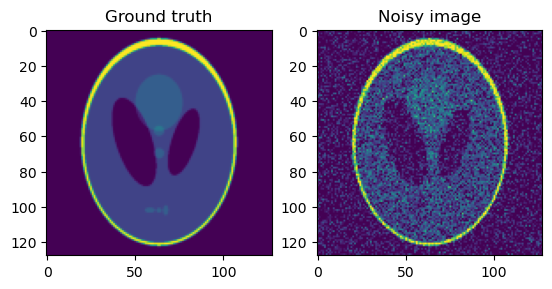

noise level, to choose epsilon 14.840271643974521


In [188]:
data_noisy = noise.gaussian(ground_truth, var = 0.02)

fig, ax = plt.subplots(1,2)
ax[0].imshow(ground_truth_array)
ax[0].set_title("Ground truth")
ax[1].imshow(data_noisy.as_array())
ax[1].set_title("Noisy image")
plt.show()

noise_norm = (data_noisy - ground_truth).norm()
print(f"noise level, to choose epsilon {noise_norm}")


In [ ]:
indicator_function = Indicator(data_noisy, epsilon = 15) # based on the norm of the noise

In [189]:
Id = IdentityOperator(ig_image)
TV = TotalVariation(backend = 'numpy')

## Using ADMM 

In [191]:
x_0 = ig_image.allocate(0)
ADMM_algo = LADMM(f = TV,g = indicator_function, operator = Id, tau = 0.5, sigma = 0.5, initial = x_0)

ADMM_algo.run(50)
sol_admm = ADMM_algo.solution

  0%|          | 0/50 [00:00<?, ?it/s]

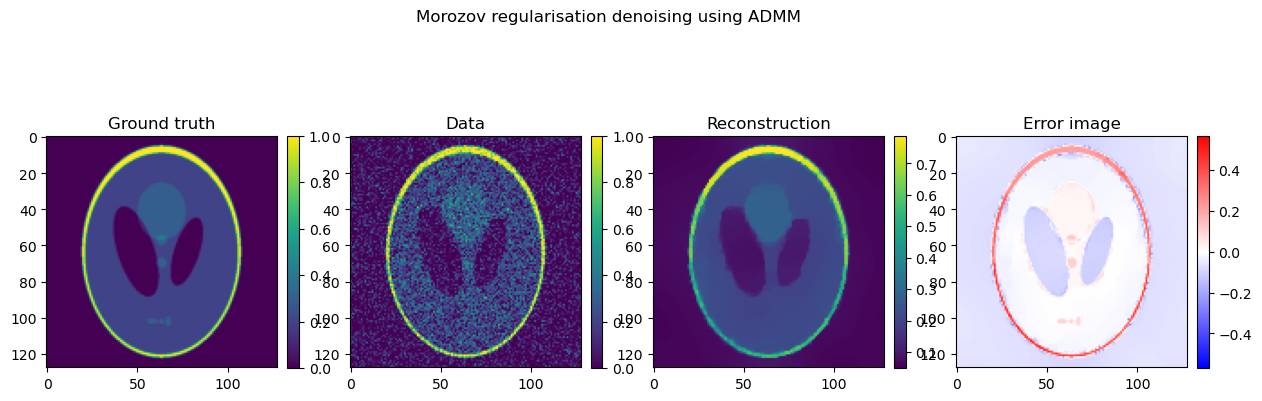

In [192]:
sol_array_admm = sol_admm.as_array()
error_admm = (ground_truth - sol_admm).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_noisy.as_array())
solution = ax[2].imshow(sol_array_admm)
error_plot = ax[3].imshow(error_admm, cmap = 'bwr', vmin = np.min([-np.max(error_admm), np.min(error_admm)]), vmax = np.max([-np.min(error_admm), np.max(error_admm)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation denoising using ADMM")
plt.show()

## Using PDHG

In [193]:
x_0 = ig_image.allocate(0)
PDHG_algo = PDHG(g = TV, f = indicator_function, operator = Id, tau = 0.5, sigma = 0.5, initial = x_0)

PDHG_algo.run(50)
sol_pdhg = PDHG_algo.solution

  0%|          | 0/50 [00:00<?, ?it/s]

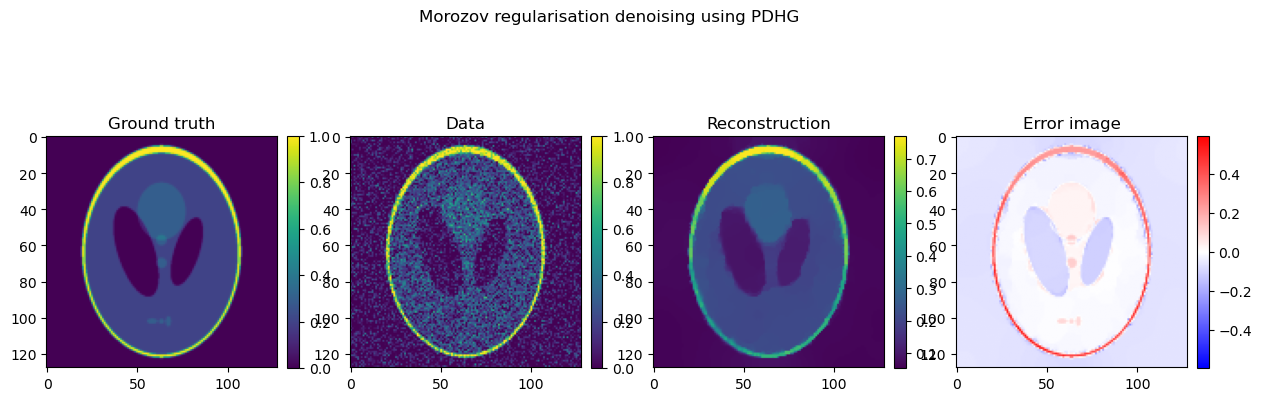

In [194]:
sol_array_pdhg = sol_pdhg.as_array()
error_pdhg = (ground_truth - sol_pdhg).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_noisy.as_array())
solution = ax[2].imshow(sol_array_pdhg)
error_plot = ax[3].imshow(error_pdhg, cmap = 'bwr', vmin = np.min([-np.max(error_pdhg), np.min(error_pdhg)]), vmax = np.max([-np.min(error_pdhg), np.max(error_pdhg)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation denoising using PDHG")
plt.show()

# Testing other inverse problems: deblurring and super-resolution

## Deblurring

In [195]:
def create_blur(ig, standard_deviation, shape):
        kernel = np.outer(sp.signal.windows.gaussian(shape[0], standard_deviation),
                        sp.signal.windows.gaussian(shape[1], standard_deviation))
        kernel = kernel*(1/np.sum(kernel))
        return BlurringOperator(kernel, ig), kernel


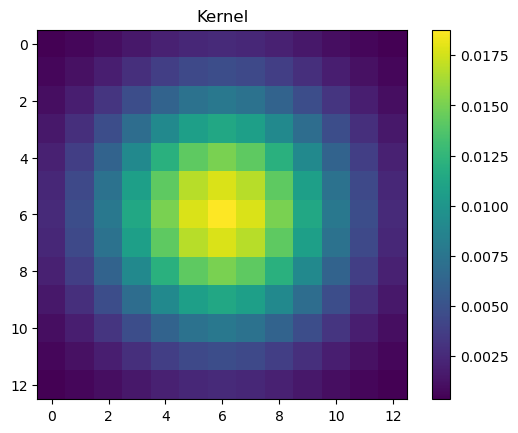

In [196]:
blurring = create_blur(ig_image, standard_deviation = 3, shape  = [13,13])[0]
kernel = create_blur(ig_image, standard_deviation = 3, shape  = [13,13])[1]

plt.imshow(kernel)
plt.colorbar()
plt.title("Kernel")
plt.show()

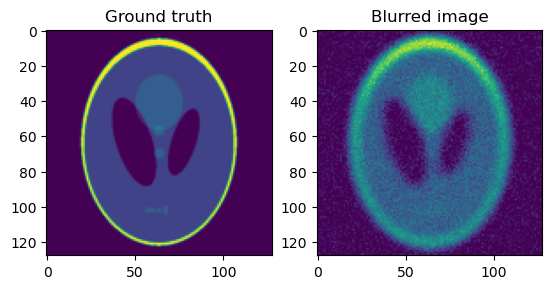

Noise level 3.584767626558647


In [197]:
data = blurring.direct(ground_truth)
data_blurred = noise.gaussian(data, var = 0.001)
fig, ax = plt.subplots(1,2)
ax[0].imshow(ground_truth_array)
ax[0].set_title("Ground truth")
ax[1].imshow(data_blurred.as_array())
ax[1].set_title("Blurred image")
plt.show()

print(f"Noise level {(blurring.direct(ground_truth) - data_blurred).norm()}")

In [198]:
indicator_function_deblurring = Indicator(data_blurred, epsilon = 4)

In [200]:
x_0 = ig_image.allocate(0)
ADMM_algo_deblur = LADMM(f = TV,g = indicator_function_deblurring, operator = blurring, tau = 1, sigma = 1, initial = x_0)

ADMM_algo_deblur.run(50)
sol_admm_deblur = ADMM_algo_deblur.solution

  0%|          | 0/50 [00:00<?, ?it/s]

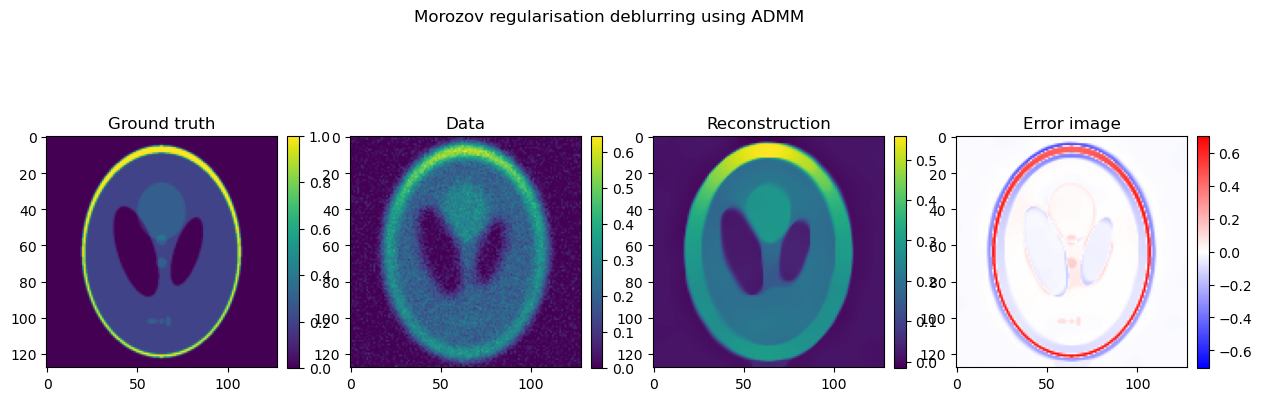

In [201]:
sol_array_admm_deblur = sol_admm_deblur.as_array()
error_admm_deblur = (ground_truth - sol_admm_deblur).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_blurred.as_array())
solution = ax[2].imshow(sol_array_admm_deblur)
error_plot = ax[3].imshow(error_admm_deblur, cmap = 'bwr', vmin = np.min([-np.max(error_admm_deblur), np.min(error_admm_deblur)]), vmax = np.max([-np.min(error_admm_deblur), np.max(error_admm_deblur)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation deblurring using ADMM")
plt.show()

In [202]:
x_0 = ig_image.allocate(0)
PDHG_algo_deblur = LADMM(f = TV,g = indicator_function_deblurring, operator = blurring, tau = 0.5, sigma = 0.5, initial = x_0)

PDHG_algo_deblur.run(50)
sol_pdhg_deblur = PDHG_algo_deblur.solution

  0%|          | 0/50 [00:00<?, ?it/s]

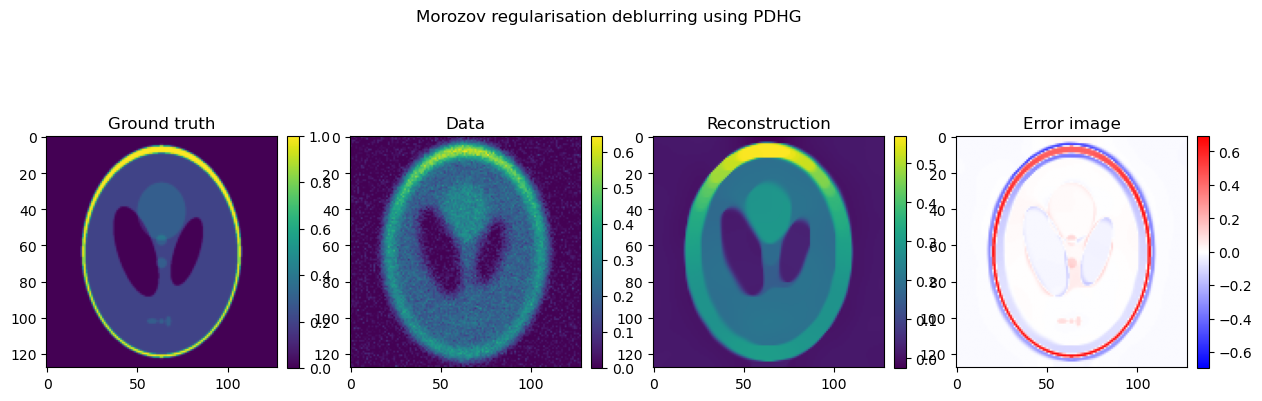

In [203]:
sol_array_pdhg_deblur = sol_pdhg_deblur.as_array()
error_pdhg_deblur = (ground_truth - sol_pdhg_deblur).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_blurred.as_array())
solution = ax[2].imshow(sol_array_pdhg_deblur)
error_plot = ax[3].imshow(error_pdhg_deblur, cmap = 'bwr', vmin = np.min([-np.max(error_pdhg_deblur), np.min(error_pdhg_deblur)]), vmax = np.max([-np.min(error_pdhg_deblur), np.max(error_pdhg_deblur)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation deblurring using PDHG")
plt.show()

## Super-resolution

In [204]:
class Downsampling(LinearOperator):
    """
    downsampling operator
    inputs: input size, downsampling step/ factor (in pixels)
    outputs: downsampling operator that can be applied to image data
    """
    def __init__(self, domain_geometry, step):
        self.ig_in = domain_geometry
        self.step = step
        I,J = self.ig_in.shape
        self.ig_out = ImageGeometry(voxel_num_x=(I//self.step) + (I % self.step >0), voxel_num_y=(J//self.step)+ (J % self.step >0)) 

        def down(u):
            return u[0:u.shape[0]:self.step,0:u.shape[1]:self.step]
         
        def up(u):
            I = self.ig_in.shape[0]
            J = self.ig_in.shape[1]
            up = np.zeros([I,J]) 
            up[0:I:self.step, 0:J:self.step] += u
            return up

        self.down = down
        self.up = up

    def direct(self,x, out = None):
        A = self.down(x.as_array()[:,:])

        # formatting output correctly:
        if out is None:
            result = self.range_geometry().allocate()
            result.fill(A)
            return result
        else:
            out.fill(A)
            return out    
        
    def adjoint(self,y, out = None):
        A_star = self.up(y.as_array()[:,:])

        # formatting output correctly:
        if out is None:
            result = self.domain_geometry().allocate()
            result.fill(A_star)
            return result
        else:
            out.fill(A_star)
            return out    
        
    def domain_geometry(self):
        return self.ig_in
    def range_geometry(self):
        return self.ig_out


In [205]:
downsampling_instance = Downsampling(blurring.range_geometry(), step = 4)
downsampling_full_operator = CompositionOperator(downsampling_instance, blurring)

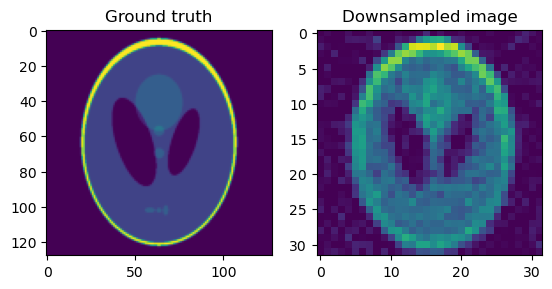

Noise level 0.8935218453407288


In [207]:
data_downsampled = downsampling_full_operator.direct(ground_truth)
data_downsampled = noise.gaussian(data_downsampled, var = 0.001)

fig, ax = plt.subplots(1,2)
ax[0].imshow(ground_truth_array)
ax[0].set_title("Ground truth")
ax[1].imshow(data_downsampled.as_array())
ax[1].set_title("Downsampled image")
plt.show()

print(f"Noise level {(downsampling_full_operator.direct(ground_truth) - data_downsampled).norm()}")

In [208]:
indicator_function_super_res = Indicator(data_downsampled, epsilon = 0.9)

In [213]:
x_0 = ig_image.allocate(0)
ADMM_algo_super_res = LADMM(f = TV,g = indicator_function_super_res, operator = downsampling_full_operator, tau = 0.5, sigma = 0.5, initial = x_0)

ADMM_algo_super_res.run(500)
sol_admm_super_res = ADMM_algo_super_res.solution

  0%|          | 0/500 [00:00<?, ?it/s]

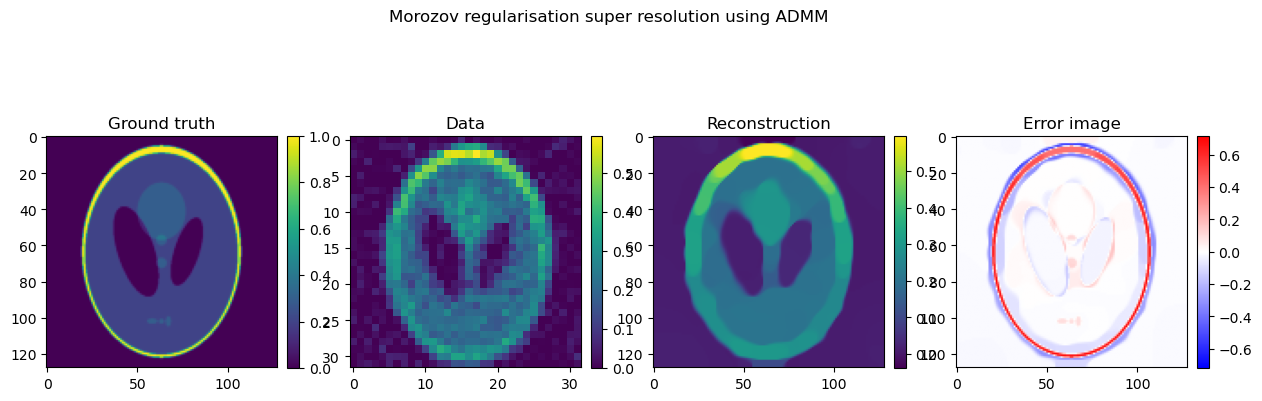

In [214]:
sol_array_admm_super_res = sol_admm_super_res.as_array()
error_admm_super_res = (ground_truth - sol_admm_super_res).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_downsampled.as_array())
solution = ax[2].imshow(sol_array_admm_super_res)
error_plot = ax[3].imshow(error_admm_super_res, cmap = 'bwr', vmin = np.min([-np.max(error_admm_super_res), np.min(error_admm_super_res)]), vmax = np.max([-np.min(error_admm_super_res), np.max(error_admm_super_res)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation super resolution using ADMM")
plt.show()

In [215]:
x_0 = ig_image.allocate(0)
PDHG_algo_super_res = PDHG(g = TV,f = indicator_function_super_res, operator = downsampling_full_operator, tau = 0.5, sigma = 0.5, initial = x_0)

PDHG_algo_super_res.run(500)
sol_pdhg_super_res = PDHG_algo_super_res.solution

  0%|          | 0/500 [00:00<?, ?it/s]

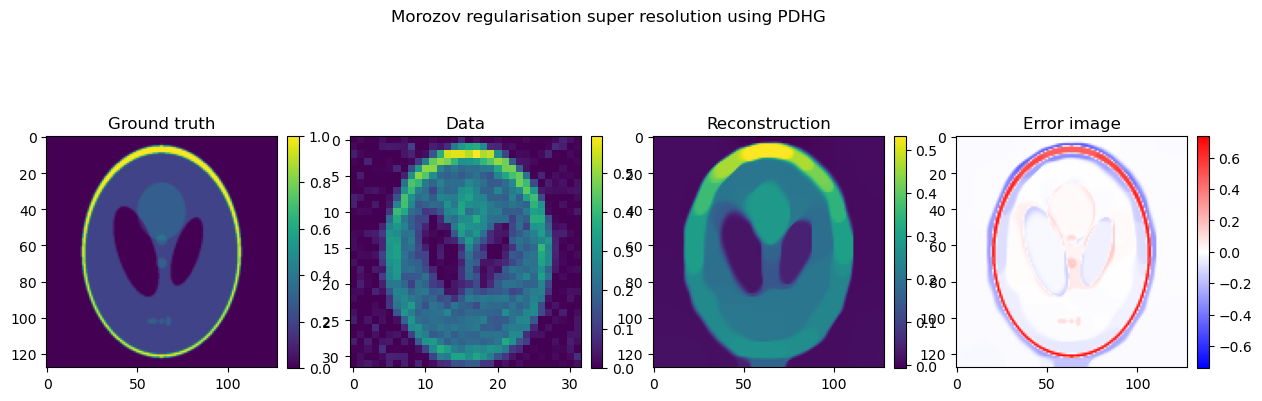

In [216]:
sol_array_pdhg_super_res = sol_pdhg_super_res.as_array()
error_pdhg_super_res = (ground_truth - sol_pdhg_super_res).as_array()
fig, ax = plt.subplots(1,4, figsize = (15,5))
ground_truth_plot = ax[0].imshow(ground_truth_array)
data_plot = ax[1].imshow(data_downsampled.as_array())
solution = ax[2].imshow(sol_array_pdhg_super_res)
error_plot = ax[3].imshow(error_pdhg_super_res, cmap = 'bwr', vmin = np.min([-np.max(error_pdhg_super_res), np.min(error_pdhg_super_res)]), vmax = np.max([-np.min(error_pdhg_super_res), np.max(error_pdhg_super_res)]))
ax[0].set_title("Ground truth")
ax[1].set_title("Data")
ax[2].set_title("Reconstruction")
ax[3].set_title('Error image')
plt.colorbar(ground_truth_plot, ax = ax[0],  fraction=0.046, pad=0.04)
plt.colorbar(data_plot, ax = ax[1],  fraction=0.046, pad=0.04)
plt.colorbar(solution, ax = ax[2],  fraction=0.046, pad=0.04)
plt.colorbar(error_plot, ax = ax[3],  fraction=0.046, pad=0.04)
plt.suptitle("Morozov regularisation super resolution using PDHG")
plt.show()